
	 	Year Fixed Effects (time dummies) + Clustered SE by Industry
                            OLS Regression Results                            
Dep. Variable:       Log_Output_Value   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                -2.754e+12
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               1.00
Time:                        23:43:17   Log-Likelihood:                 444.79
No. Observations:                 504   AIC:                            -833.6
Df Residuals:                     476   BIC:                            -715.3
Df Model:                          27                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

c:\Users\hwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 26
  warnings.warn('covariance of constraints does not have full '


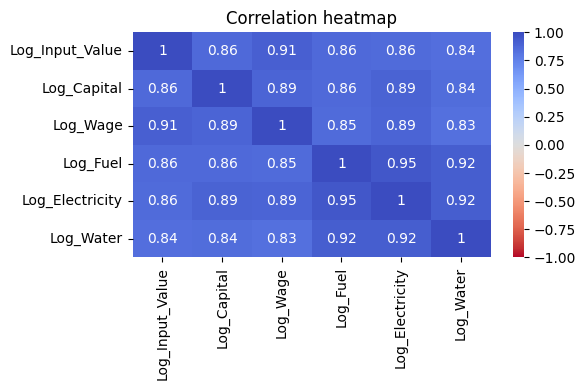

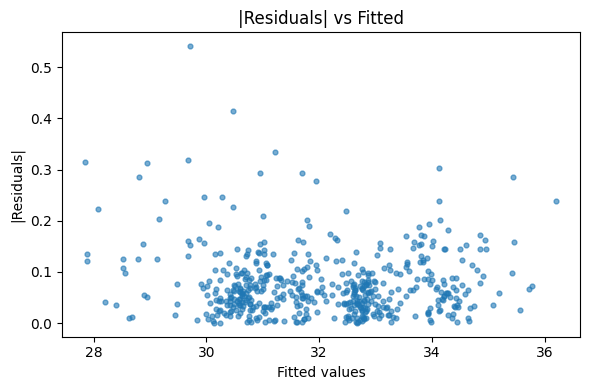

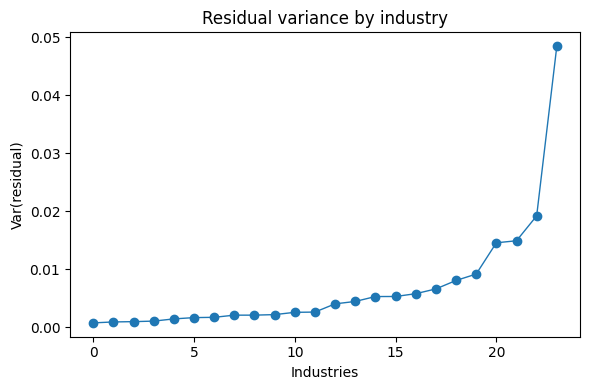

In [1]:
"""
One-way Fixed Effects (Year) for panel data 
using cluster-robust standard errors at Industry level.

"""

import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# 0) Display options + load settings
# -----------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.1f}".format)

with open("../../Settings.yaml", "r") as file:
    Setting = yaml.safe_load(file)

# -----------------------------
# 1) Load datasets
#   - Main panel dataset
#   - Separate dataset containing a (generated) industry effect measure
# -----------------------------
file_path = f"{Setting['Output_Path_Ajusted']}/Adjusted.xlsx"
Dataset = pd.read_excel(file_path,sheet_name='Dataset_for_Model')
FE_Dataset = pd.read_excel(file_path,sheet_name='Industry_Productivity')

# -----------------------------
# 2) Create Year fixed effects (year dummy variables)
#   drop_first=True avoids the dummy-variable trap (perfect multicollinearity).
# -----------------------------
year_dum = pd.get_dummies(Dataset["Year"], prefix="Y", drop_first=True)

# -----------------------------
# 3) Log-transform variables used in the model
#   Note: make sure original variables are strictly positive before taking logs.
# -----------------------------
for c in ["Output_Value", "Input_Value", "Capital", "Wage", "Fuel", "Electricity", "Water"]:
    Dataset["Log_" + c] = np.log(Dataset[c])

# -----------------------------
# 4) Merge generated industry-effect measure (NOT true industry fixed effects)
#   This variable is treated as a regressor in this specification.
# -----------------------------
Dataset = Dataset.merge(
    FE_Dataset[["Industry_Code", "Log_Industry_Effect"]],
    on="Industry_Code",
    how="left"
)

# -----------------------------
# 5) Build regressor matrix X:
#   - Core inputs (log-log Cobb-Douglas style)
#   - Generated industry effect measure
#   - Year dummies (time fixed effects)
# -----------------------------
X = pd.concat(
    [
        Dataset[
            [
                "Log_Input_Value",
                "Log_Capital",
                "Log_Wage",
                "Log_Fuel",
                "Log_Electricity",
                "Log_Water",
                "Log_Industry_Effect",
            ]
        ],
        year_dum,
    ],
    axis=1,
).astype("float64")

X = sm.add_constant(X, has_constant="add")
y = Dataset["Log_Output_Value"].astype("float64")

# -----------------------------
# 6) Estimate OLS and compute cluster-robust SE by industry
#   Clustering at industry level allows:
#   - heteroskedasticity across industries
#   - serial correlation within each industry over time
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": Dataset["Industry_Code"]},
)

print("\n" + "=" * 80)
print("\t \tYear Fixed Effects (time dummies) + Clustered SE by Industry")
print("=" * 80)
print(model.summary())

# -----------------------------
# 7) Heteroskedasticity diagnostic (Breusch–Pagan)
# -----------------------------
bp = het_breuschpagan(model.resid, model.model.exog)
labels = ["LM stat", "LM p-value", "F stat", "F p-value"]

print("\n" + "=" * 80)
print("Breusch–Pagan test:")
print(dict(zip(labels, bp)))
print("=" * 80)

# -----------------------------
# 8) Multicolinearity (VIF Test)
# -----------------------------
cont_cols = ["Log_Input_Value","Log_Capital","Log_Wage","Log_Fuel","Log_Electricity","Log_Water"]
X_cont = sm.add_constant(Dataset[cont_cols].astype(float))
vif = pd.DataFrame({
    "var": X_cont.columns,
    "VIF": [variance_inflation_factor(X_cont.values, i) for i in range(X_cont.shape[1])]
})
print("\n" + "=" * 80)
print("VIF test :")
print(vif.sort_values("VIF", ascending=False))
print("=" * 80)

# -----------------------------
# 9) Visual diagnostic: Multicolinearity
# -----------------------------
corr = Dataset[cont_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm_r", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Visual diagnostic: |residuals| vs fitted
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.abs(resid), s=12, alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("|Residuals|")
plt.title("|Residuals| vs Fitted")
plt.tight_layout()
plt.show()

# -----------------------------
# 11) Residual variance by industry (descriptive)
# -----------------------------
Dataset = Dataset.copy()
Dataset["resid"] = resid

var_by_ind = Dataset.groupby("Industry_Code")["resid"].var().sort_values()

plt.figure(figsize=(6, 4))
plt.plot(var_by_ind.values, marker="o", linewidth=1)
plt.xlabel("Industries")
plt.ylabel("Var(residual)")
plt.title("Residual variance by industry")
plt.tight_layout()
plt.show()